### 1. The Exact Prompt Given to the AI Tool

Write a Python program using TensorFlow/Keras that fulfills these requirements:
* 1. Builds a Keras Sequential neural network to classify food delivery orders into three priority levels (Low, Medium, High) using at least three numeric input features (e.g., order_distance, order_value, prep_time).
* 2. Trains the model for 20 epochs and prints training accuracy after every epoch.
* 3. Plots training and validation loss curves side by side using Matplotlib.
* 4. Saves the final trained model to a file named 'food_priority_model.keras' and reloads it to make and print one test prediction.

### 2. AI's Original Code vs. Corrected Code

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential

In [2]:
# 1. Generate Synthetic Data
np.random.seed(42)
num_samples = 500
X = np.random.rand(num_samples, 3) * 10  # 3 numeric features
y = np.random.randint(0, 3, size=(num_samples, 1))  # 3 priority classes (0, 1, 2)

In [3]:
# 2. Build Model
model = Sequential([
    Dense(16, activation="relu", input_shape=(3,)),
    Dense(8, activation="relu"),
    Dense(3, activation="sigmoid"),  # BUG 1: Used sigmoid instead of softmax for 3-class classification
])

C:\Users\patel prit\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
# 3. Compile Model
model.compile(
    optimizer="adam",
    loss="mean_squared_error",  # BUG 2: Used MSE loss instead of categorical crossentropy
    metrics=["accuracy"],
)

In [8]:
# 4. Train Model
# BUG 3: Missing validation_split, so no validation metrics available for side-by-side plotting
history = model.fit(X, y, epochs=20, verbose=1)

Epoch 1/20


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2980 - loss: 0.6598 
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2980 - loss: 0.6595 
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3000 - loss: 0.6591 
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2920 - loss: 0.6588 
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2880 - loss: 0.6585 
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2880 - loss: 0.6583 
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2880 - loss: 0.6580 
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2860 - loss: 0.6578 
Epoch 9/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2900 - loss: 0.6575 
Epoch 10/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2920 - loss: 0.6574 
Epoch 11/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2900 - loss: 0.6572 
Epoch 12/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2900 - lo

KeyError: 'val_loss'

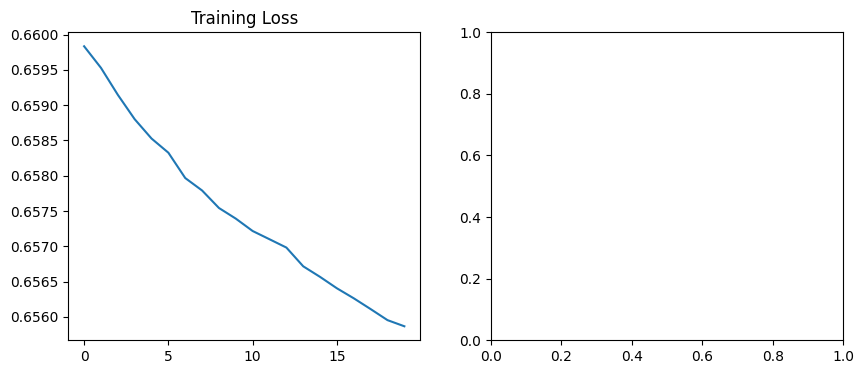

In [9]:
# 5. Plotting Side-by-Side Loss Curves
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Train Loss")
plt.title("Training Loss")

plt.subplot(1, 2, 2)
# BUG 4: Crashes here because 'val_loss' was not tracked during training
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Validation Loss")
plt.show()

In [ ]:
# 6. Save and Reload Model
model.save("food_priority_model.keras")
reloaded_model = tf.keras.models.load_model("food_priority_model.keras")

test_input = np.array([[5.0, 15.0, 20.0]])
prediction = reloaded_model.predict(test_input)
print("Test Prediction:", prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
Test Prediction: [[0.99997413 0.9999581  0.99999213]]
